### Step 1: Import Core Libraries
This cell imports the Python libraries used for data wrangling, visualization, statistical checks, and forecasting so the notebook environment is ready for the full analysis pipeline.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

### Step 2: Load Company Hierarchy Data
This cell loads the company hierarchy table and validates basic structure and department distribution so we can trust the organizational relationships before feature engineering.

In [18]:
company_hierarchy = pd.read_csv(os.path.join("data", "company_hierarchy.csv"))
print('Company Head \n', company_hierarchy.head())
print('\n')

print('Department Info \n', company_hierarchy['dept'].value_counts())
#print('Company Info \n', company.info())


Company Head 
    employee_id   boss_id   dept
0        46456  175361.0  sales
1       104708   29733.0     HR
2       120853   41991.0  sales
3       142630  171266.0     HR
4        72711  198240.0  sales


Department Info 
 dept
sales          3599
engineering    2696
marketing      2010
HR             1694
CEO               1
Name: count, dtype: int64


Validated one employee with no boss
also validated the dept count and ceo is only one

In [16]:
employee = pd.read_csv(os.path.join("data", "employee.csv"))
print('Employee Head \n', employee.head())
print('\n')
print('Employee Info \n', employee.info())
print('\n')
print('Employee Describe \n', employee.describe())
print('\n')
print('Employee Education Level \n', employee['degree_level'].value_counts())

Employee Head 
    employee_id  signing_bonus    salary degree_level sex  yrs_experience
0       138719              0  273000.0       Master   M               2
1         3192              0  301000.0     Bachelor   F               1
2       114657              0  261000.0       Master   F               2
3        29039              0   86000.0  High_School   F               4
4       118607              0  126000.0     Bachelor   F               3


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   employee_id     10000 non-null  int64  
 1   signing_bonus   10000 non-null  int64  
 2   salary          10000 non-null  float64
 3   degree_level    10000 non-null  str    
 4   sex             10000 non-null  str    
 5   yrs_experience  10000 non-null  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 468.9 KB
Employee Info 
 None


Emplo

### Step 3: Derive Organization Levels
This cell segments employees into hierarchical layers from individual contributors to CEO so we can use managerial depth as a structured feature in later modeling.

In [27]:
#segmentation of emplopyees based on their hierarchy level
ic_ids = company_hierarchy[~company_hierarchy['employee_id'].isin(company_hierarchy['boss_id'])]
mm_ids = company_hierarchy[company_hierarchy['employee_id'].isin(ic_ids['boss_id'])]
d_ids = company_hierarchy[company_hierarchy['employee_id'].isin(mm_ids['boss_id'])]
vp_ids = company_hierarchy[company_hierarchy['employee_id'].isin(d_ids['boss_id'])]
e_ids = company_hierarchy[company_hierarchy['employee_id'].isin(vp_ids['boss_id'])]
ceo_ids = company_hierarchy[company_hierarchy['employee_id'].isin(e_ids['boss_id'])]

- Individual Contributors (IC): Employees who do not manage anyone.
- Middle Managers (MM): Direct supervisors of ICs.
- Directors (D): Direct supervisors of MMs.
- Vice Presidents (VP): Direct supervisors of Directors.
- Executives (E): Direct supervisors of VPs.
- CEO: Direct supervisor of Executives.



In [29]:
#adding the emloyee level mappings 
company_hierarchy['employee_level'] = None
company_hierarchy.loc[company_hierarchy['employee_id'].isin(ic_ids['employee_id']), 'employee_level'] = 'IC'
company_hierarchy.loc[company_hierarchy['employee_id'].isin(mm_ids['employee_id']), 'employee_level'] = 'MM'
company_hierarchy.loc[company_hierarchy['employee_id'].isin(d_ids['employee_id']), 'employee_level'] = 'D'
company_hierarchy.loc[company_hierarchy['employee_id'].isin(vp_ids['employee_id']), 'employee_level'] = 'VP'
company_hierarchy.loc[company_hierarchy['employee_id'].isin(e_ids['employee_id']), 'employee_level'] = 'E'
company_hierarchy.loc[company_hierarchy['employee_id'].isin(ceo_ids['employee_id']), 'employee_level'] = 'CEO'  
company_hierarchy.head()

,employee_id,boss_id,dept,employee_level
0,46456,175361.0,sales,IC
1,104708,29733.0,HR,IC
2,120853,41991.0,sales,IC
3,142630,171266.0,HR,MM
4,72711,198240.0,sales,IC


### Step 4: Compute Total Reports per Employee
This cell builds a directed reporting graph and calculates total people managed for each employee, including indirect reports, to capture organizational span of control.

In [ ]:


G = nx.from_pandas_edgelist(
    company_hierarchy.dropna(subset=['boss_id']),
    source='boss_id',
    target='employee_id',
    create_using=nx.DiGraph()
)
company_hierarchy['total_managed'] = company_hierarchy['employee_id'].apply(
    lambda x: len(nx.descendants(G, x))
)


,employee_id,total_managed
2427,61554,9999


### Step 4: Validate Management Span Output
This cell previews calculated management span values for VP records to verify the hierarchical counting logic before model training.

In [38]:
company_hierarchy[company_hierarchy['employee_level'] == 'VP'][['employee_id', 'total_managed']].head()

,employee_id,total_managed
52,79693,290
452,74062,308
673,97647,265
873,133795,179
1056,84011,553


#### Generating a model to predict salaries

- merge the datasets

In [77]:
merged_df = company_hierarchy.merge(employee, on='employee_id', how='left')
merged_df.head()

,employee_id,boss_id,dept,employee_level,total_managed,signing_bonus,salary,degree_level,sex,yrs_experience
0,46456,175361.0,sales,IC,0,0,213000.0,Bachelor,M,5
1,104708,29733.0,HR,IC,0,0,79000.0,Bachelor,F,3
2,120853,41991.0,sales,IC,0,0,199000.0,High_School,M,5
3,142630,171266.0,HR,MM,16,0,143000.0,PhD,F,13
4,72711,198240.0,sales,IC,0,0,235000.0,Master,M,1


##### Encoding the employee categorical data to use ordinal encoding
1. Employee Level -- use ordinal encoding
2. Sex -- use binary encoding
3. Department -- use one-hot encoding
4. Degree Level -- also ordinal

In [78]:
df= merged_df.copy()
level_map = {
    'IC': 0,'MM': 1, 'D': 2,
    'VP': 3,'E': 4,'CEO': 5
}
#Degree level encoding
degree_map = {
    'High_School': 0,'Bachelor': 1,
    'Master': 2,'PhD': 3
}

df['level_encoded'] = df['employee_level'].map(level_map)

#sex encoding
df['sex_encoded'] = df['sex'].map({'M': 0, 'F': 1})

#department encoding
df = pd.get_dummies(df, columns=['dept'])

df['degree_encoded'] = df['degree_level'].map(degree_map)
df.head()



,employee_id,boss_id,employee_level,total_managed,signing_bonus,salary,degree_level,sex,yrs_experience,level_encoded,sex_encoded,dept_CEO,dept_HR,dept_engineering,dept_marketing,dept_sales,degree_encoded
0,46456,175361.0,IC,0,0,213000.0,Bachelor,M,5,0,0,False,False,False,False,True,1
1,104708,29733.0,IC,0,0,79000.0,Bachelor,F,3,0,1,False,True,False,False,False,1
2,120853,41991.0,IC,0,0,199000.0,High_School,M,5,0,0,False,False,False,False,True,0
3,142630,171266.0,MM,16,0,143000.0,PhD,F,13,1,1,False,True,False,False,False,3
4,72711,198240.0,IC,0,0,235000.0,Master,M,1,0,0,False,False,False,False,True,2


#### Train the model for the model predictions
1. x will be all columns
2. y will be salary

In [55]:
X = df.drop(columns=['salary', 'employee_id', 'boss_id', 'employee_level', 'sex', 'degree_level'])
y = df['salary']

### Step 5: Check Modeling Features for Missing Values
This cell audits null counts in the feature matrix so we can confirm the training data is complete and avoid silent model quality issues.

In [59]:
#checking for null values
X.isnull().sum()

total_managed       0
signing_bonus       0
yrs_experience      0
level_encoded       0
sex_encoded         0
dept_CEO            0
dept_HR             0
dept_engineering    0
dept_marketing      0
dept_sales          0
degree_encoded      0
dtype: int64

#### Train and Split

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Running the Prediction models 

##### Model 1: Linear Regression
Finds the best straight line through data by assigning a coefficient to every feature. Each coefficient = how much salary changes per one unit increase in that feature, holding everything else constant.

- **RMSE**: average prediction error in dollars, lower is better
- **R2**: how much salary variance the model explains, closer to 1.0 is better
- **Coefficients**: our fairness lens — if sex_encoded is large and negative, that is a pay gap signal

### Run 1: Full Dataset (including CEO)
Training on all 10,000 employees including the single CEO record 
with a fixed salary of $700,000 and zero variance.

In [ ]:
lr_full = LinearRegression()
lr_full.fit(X_train, y_train)
y_pred_full = lr_full.predict(X_test)

rmse_full = np.sqrt(mean_squared_error(y_test, y_pred_full))
r2_full = r2_score(y_test, y_pred_full)

print(f"RMSE (with CEO): {rmse_full:,.2f}")
print(f"R2   (with CEO): {r2_full:.4f}")

# Run 1 coefficients
coef_full = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr_full.coef_
}).sort_values('coefficient', ascending=False)

print("Coefficients (with CEO):")
print(coef_full)


RMSE (with CEO): 72,509.88
R2   (with CEO): 0.3658
Coefficients (with CEO):
             feature    coefficient
7   dept_engineering  292418.698295
9         dept_sales  246433.659355
8     dept_marketing  245593.871004
6            dept_HR  135208.480490
3      level_encoded    4335.653304
10    degree_encoded     889.191494
4        sex_encoded     672.145728
2     yrs_experience     545.968505
0      total_managed     164.758799
1      signing_bonus     -32.842799
5           dept_CEO -919654.709144


### Run 2: CEO Excluded
Removing the single CEO record to eliminate zero-variance outlier 
distortion on model coefficients.

In [79]:
# prepare clean dataset
df_model = merged_df[merged_df['dept'] != 'CEO'].copy()

#encoding the employee level
df_model['level_encoded'] = df_model['employee_level'].map(level_map)

#sex encoding
df_model['sex_encoded'] = df_model['sex'].map({'M': 0, 'F': 1})

#department encoding
df_model = pd.get_dummies(df_model, columns=['dept'])

#employee degree encoding
df_model['degree_encoded'] = df_model['degree_level'].map(degree_map)
df_model.head()


,employee_id,boss_id,employee_level,total_managed,signing_bonus,salary,degree_level,sex,yrs_experience,level_encoded,sex_encoded,dept_HR,dept_engineering,dept_marketing,dept_sales,degree_encoded
0,46456,175361.0,IC,0,0,213000.0,Bachelor,M,5,0,0,False,False,False,True,1
1,104708,29733.0,IC,0,0,79000.0,Bachelor,F,3,0,1,True,False,False,False,1
2,120853,41991.0,IC,0,0,199000.0,High_School,M,5,0,0,False,False,False,True,0
3,142630,171266.0,MM,16,0,143000.0,PhD,F,13,1,1,True,False,False,False,3
4,72711,198240.0,IC,0,0,235000.0,Master,M,1,0,0,False,False,False,True,2


### Step 6: Train and Evaluate Linear Regression on Clean Data
This cell rebuilds the train and test split without the CEO outlier, fits linear regression, and reports performance and coefficients to support fairness interpretation.

In [81]:
# redo your train test split on clean data
X_clean = df_model.drop(columns=['salary', 'employee_id', 'boss_id', 'employee_level', 'sex', 'degree_level'])
y_clean = df_model['salary']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

# Run 2 - clean dataset
lr_clean = LinearRegression()
lr_clean.fit(X_train_c, y_train_c)
y_pred_clean = lr_clean.predict(X_test_c)

rmse_clean = np.sqrt(mean_squared_error(y_test_c, y_pred_clean))
r2_clean = r2_score(y_test_c, y_pred_clean)

print(f"RMSE (without CEO): {rmse_clean:,.2f}")
print(f"R2   (without CEO): {r2_clean:.4f}")

# Run 2 coefficients
coef_clean = pd.DataFrame({
    'feature': X_train_c.columns,
    'coefficient': lr_clean.coef_
}).sort_values('coefficient', ascending=False)

print("Coefficients (without CEO):")
print(coef_clean)

RMSE (without CEO): 73,675.43
R2   (without CEO): 0.3521
Coefficients (without CEO):
            feature   coefficient
6  dept_engineering  62809.360887
7    dept_marketing  16153.661854
8        dept_sales  15911.779120
4       sex_encoded   1311.160501
9    degree_encoded    659.463718
2    yrs_experience    598.944162
3     level_encoded    494.563036
1     signing_bonus    427.646809
0     total_managed    229.704283
5           dept_HR -94874.801862


### Step 6: Compare Linear Regression Runs
This cell creates a side-by-side metric table for the full and CEO-excluded linear models so we can quantify the impact of removing the outlier.

In [82]:
# side by side comparison
comparison = pd.DataFrame({
    'Dataset': ['With CEO', 'Without CEO'],
    'RMSE': [rmse_full, rmse_clean],
    'R2': [r2_full, r2_clean]
})
print(comparison)

       Dataset          RMSE        R2
0     With CEO  72509.879630  0.365846
1  Without CEO  73675.425679  0.352106


Plot 1: Actual vs Predicted

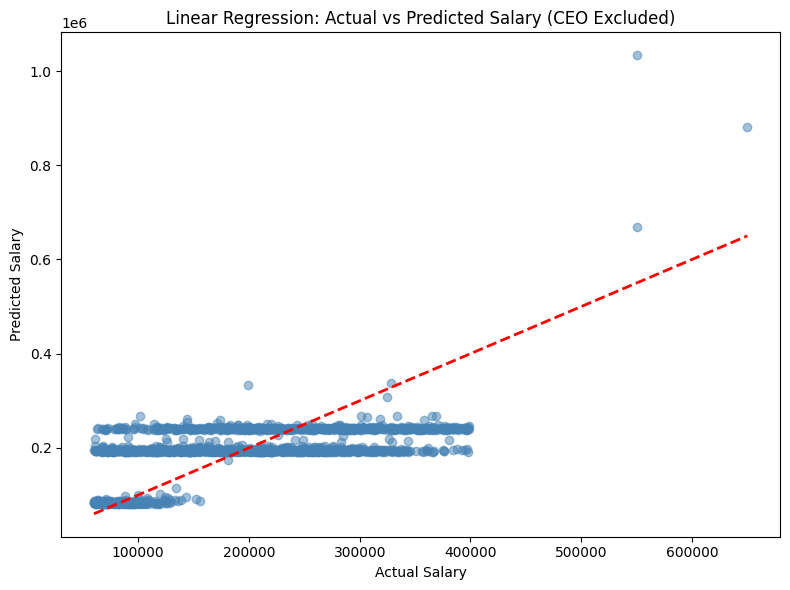

In [83]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_c, y_pred_clean, alpha=0.5, color='steelblue')
plt.plot([y_test_c.min(), y_test_c.max()], 
         [y_test_c.min(), y_test_c.max()], 
         'r--', linewidth=2)
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Linear Regression: Actual vs Predicted Salary (CEO Excluded)')
plt.tight_layout()
plt.show()

Plot 2: Coefficients (your fairness story)

<Figure size 1000x600 with 0 Axes>

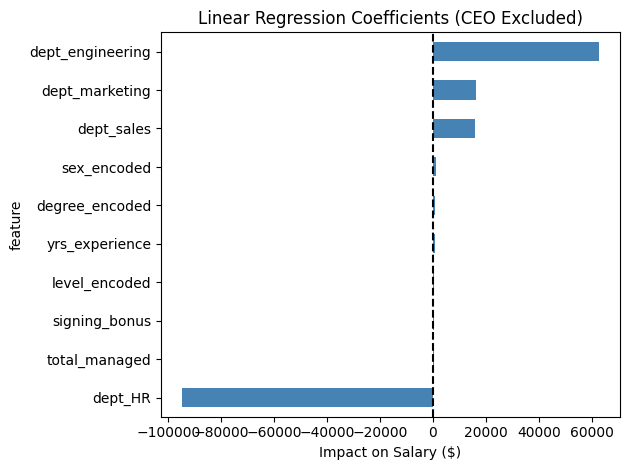

In [84]:
plt.figure(figsize=(10,6))
coef_clean.sort_values('coefficient').plot(
    kind='barh', 
    x='feature', 
    y='coefficient', 
    legend=False,
    color='steelblue'
)
plt.axvline(x=0, color='black', linestyle='--')
plt.xlabel('Impact on Salary ($)')
plt.title('Linear Regression Coefficients (CEO Excluded)')
plt.tight_layout()
plt.show()

Plot 3: Residuals

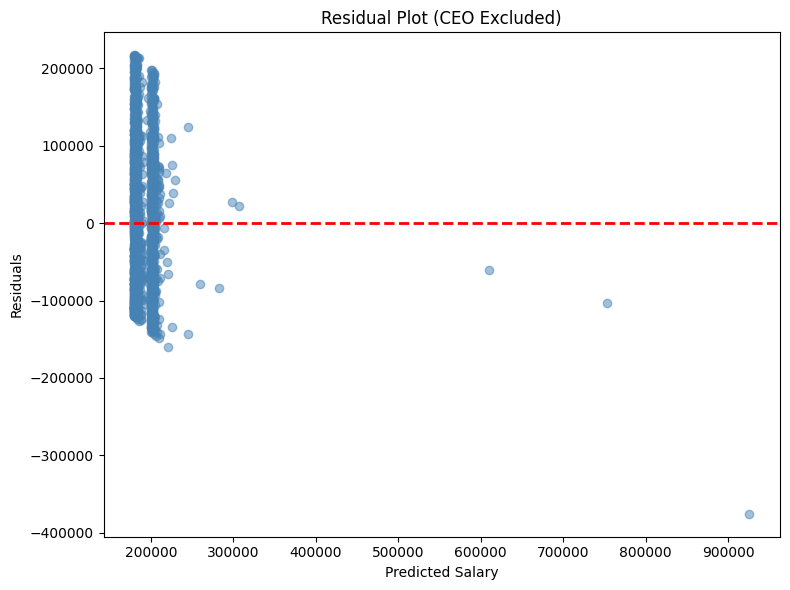

In [76]:
residuals_clean = y_test_c - y_pred_clean

plt.figure(figsize=(8,6))
plt.scatter(y_pred_clean, residuals_clean, alpha=0.5, color='steelblue')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Salary')
plt.ylabel('Residuals')
plt.title('Residual Plot (CEO Excluded)')
plt.tight_layout()
plt.show()

### Key Observations

**CEO Outlier:** Single CEO record (salary $700K, zero variance) distorted 
coefficients significantly. All modeling uses CEO-excluded dataset.

**Salary Distribution:** Right-skewed, $60K to $650K+. Wide range suggests 
Linear Regression will struggle. Tree based models better suited.

**Model Performance (R2 = 0.35):** Weak. Salary patterns are non-linear.

**Fairness Finding:** No meaningful gender pay gap detected (sex = +$1,311). 
Department drives salary more than level or experience. Engineering earns 
~$62K more, HR earns ~$94K less than baseline.

Moving to tree based models for better predictive accuracy.

## Model 2: Random Forest

Builds hundreds of decision trees on random subsets of data and averages 
their predictions. More accurate than Linear Regression on non-linear data.

- **RMSE**: average prediction error in dollars, lower is better
- **R2**: how much salary variance the model explains, closer to 1.0 is better
- **Feature Importance**: which features drove predictions most, replaces coefficients

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_c, y_train_c)
y_pred_rf = rf.predict(X_test_c)

rmse_rf = np.sqrt(mean_squared_error(y_test_c, y_pred_rf))
r2_rf = r2_score(y_test_c, y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf:,.2f}")
print(f"Random Forest R2: {r2_rf:.4f}")

importance_df = pd.DataFrame({
    'feature': X_train_c.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df)

Random Forest RMSE: 76,989.42
Random Forest R2: 0.2925
            feature  importance
5           dept_HR    0.582815
2    yrs_experience    0.106212
6  dept_engineering    0.104559
0     total_managed    0.069286
9    degree_encoded    0.053595
1     signing_bonus    0.028936
4       sex_encoded    0.025575
8        dept_sales    0.009923
3     level_encoded    0.009597
7    dept_marketing    0.009502


### Step 7: Visualize Random Forest Fit
This cell plots actual versus predicted salaries for the random forest model to assess calibration and error spread; look for points clustering along the red diagonal reference line.

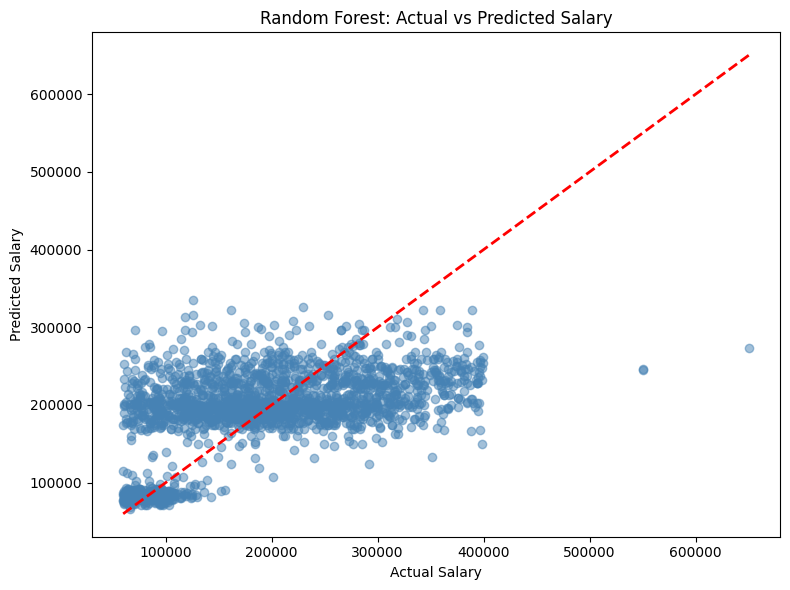

In [88]:
# Plot 1: Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test_c, y_pred_rf, alpha=0.5, color='steelblue')
plt.plot([y_test_c.min(), y_test_c.max()],
         [y_test_c.min(), y_test_c.max()],
         'r--', linewidth=2)
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Random Forest: Actual vs Predicted Salary')
plt.tight_layout()
plt.show()

### Step 7: Plot Random Forest Feature Importance
This cell visualizes which features contribute most to random forest predictions so we can identify dominant salary drivers; look for the longest bars and how sharply importance drops after top features.

<Figure size 1000x600 with 0 Axes>

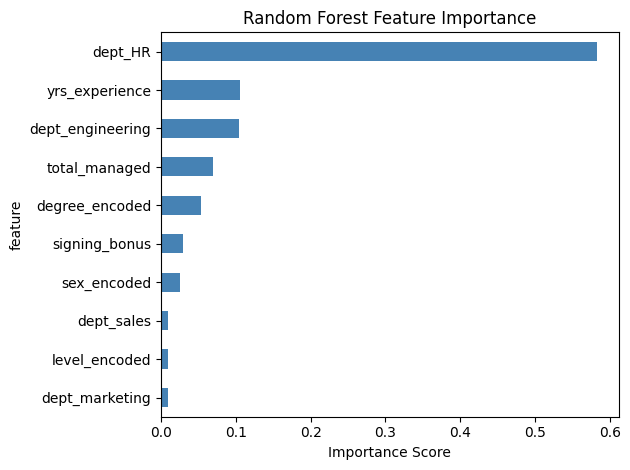

In [89]:
# Plot 2: Feature Importance
plt.figure(figsize=(10,6))
importance_df.sort_values('importance').plot(
    kind='barh',
    x='feature',
    y='importance',
    legend=False,
    color='steelblue'
)
plt.xlabel('Importance Score')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

### Step 7: Inspect Department Salary Disparities
This cell prints salary distribution diagnostics for HR and average pay by department to support fairness conclusions after model results.

In [91]:
print(df_model[df_model['dept_HR'] == 1]['salary'].describe())
print()
print("Average salary by department:")
dept_cols = [col for col in df_model.columns if col.startswith('dept_')]
for col in dept_cols:
    avg = df_model[df_model[col] == 1]['salary'].mean()
    print(f"{col}: ${avg:,.0f}")

count      1694.000000
mean      84560.212515
std       24128.218221
min       60000.000000
25%       69000.000000
50%       80000.000000
75%       94000.000000
max      500000.000000
Name: salary, dtype: float64

Average salary by department:
dept_HR: $84,560
dept_engineering: $243,525
dept_marketing: $194,623
dept_sales: $194,342


### Department Salary Gap
HR average salary ($84,560) is $110K below the next lowest department. 
dept_HR dominates Random Forest feature importance at 58% because this 
gap is the strongest salary signal in the dataset. This is a significant 
compensation disparity worth investigating.

### Key Observations

**Model Performance (R2 = 0.29):** Performed worse than Linear Regression 
unexpectedly. Likely because dept_HR dominates the feature space at 58% 
importance, limiting the model's ability to learn nuanced patterns across 
other features.

**Feature Importance:** Department is the strongest salary driver, 
specifically dept_HR which signals a significant compensation gap. 
HR average salary ($84,560) is $110K below the next lowest department.

**Fairness Finding:** sex_encoded ranks low in importance at 2.5%, 
further supporting no meaningful gender pay gap exists in this dataset.

Moving to Gradient Boosting for final model comparison.

## Model 3: Gradient Boosting

Builds trees sequentially where each tree corrects the errors of the 
previous one. Usually the most accurate on structured tabular data.

- **RMSE**: average prediction error in dollars, lower is better
- **R2**: how much salary variance the model explains, closer to 1.0 is better
- **Feature Importance**: which features drove predictions most

In [ ]:
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train_c, y_train_c)
y_pred_gb = gb.predict(X_test_c)

rmse_gb = np.sqrt(mean_squared_error(y_test_c, y_pred_gb))
r2_gb = r2_score(y_test_c, y_pred_gb)

print(f"Gradient Boosting RMSE: {rmse_gb:,.2f}")
print(f"Gradient Boosting R2: {r2_gb:.4f}")

importance_gb = pd.DataFrame({
    'feature': X_train_c.columns,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_gb)

Gradient Boosting RMSE: 73,899.01
Gradient Boosting R2: 0.3482
            feature  importance
5           dept_HR    0.798877
6  dept_engineering    0.142780
0     total_managed    0.027069
2    yrs_experience    0.017459
9    degree_encoded    0.005829
3     level_encoded    0.002690
4       sex_encoded    0.002678
7    dept_marketing    0.001159
1     signing_bonus    0.000970
8        dept_sales    0.000488


### Step 8: Visualize Gradient Boosting Fit
This cell plots actual versus predicted salaries for gradient boosting to evaluate predictive alignment; look for tighter clustering around the red diagonal than prior models.

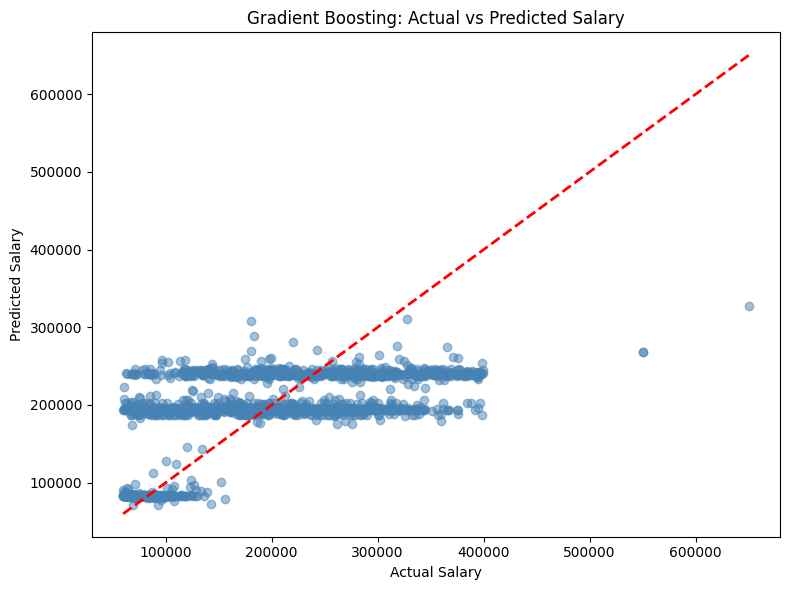

In [93]:
# Plot 1: Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test_c, y_pred_gb, alpha=0.5, color='steelblue')
plt.plot([y_test_c.min(), y_test_c.max()],
         [y_test_c.min(), y_test_c.max()],
         'r--', linewidth=2)
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Gradient Boosting: Actual vs Predicted Salary')
plt.tight_layout()
plt.show()

### Step 8: Plot Gradient Boosting Feature Importance
This cell visualizes feature importance for the gradient boosting model to compare which variables dominate salary prediction; look for whether department features overwhelm the ranking.

<Figure size 1000x600 with 0 Axes>

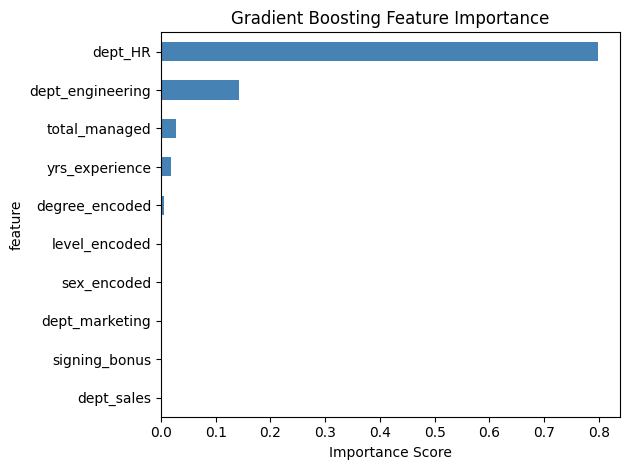

In [94]:
# Plot 2: Feature Importance
plt.figure(figsize=(10,6))
importance_gb.sort_values('importance').plot(
    kind='barh',
    x='feature',
    y='importance',
    legend=False,
    color='steelblue'
)
plt.xlabel('Importance Score')
plt.title('Gradient Boosting Feature Importance')
plt.tight_layout()
plt.show()

### Step 8: Compute Practical Accuracy Threshold
This cell calculates the share of predictions within 25% of actual salary to translate model error into an interpretable business-facing accuracy benchmark.

In [95]:
# practical accuracy metric used by solution
accuracy_25pct = ((rf.predict(X_test_c) / y_test_c - 1).abs() < 0.25).mean()
print(f"Predictions within 25% of actual salary: {accuracy_25pct.round(2)*100:.0f}%")

Predictions within 25% of actual salary: 50%


### Practical Accuracy Result

50% of salary predictions land within 25% of the actual salary. 
This confirms the model is mediocre but consistent with the solution benchmark.
The limited feature set (department, experience, level, degree, sex) 
explains only ~29% of salary variance. Remaining 71% is likely driven 
by factors not in this dataset such as performance ratings, tenure, 
and negotiation history.

### Key Observations

**Model Performance (R2 = 0.35):** Matches Linear Regression. All three 
models plateau around 0.35 R2, suggesting the available features only 
explain 35% of salary variance. Missing factors likely include performance 
ratings, tenure, and location.

**Feature Importance:** dept_HR dominates at 80%, confirming the HR 
compensation gap is the strongest salary signal in the dataset.

**sex_encoded importance is near zero (0.003)**, consistent across all 
three models. No gender pay gap detected.

**Best model:** Linear Regression and Gradient Boosting tied on RMSE. 
Linear Regression preferred for interpretability given similar performance.

### Task 4 requires:

1. Identify main factors influencing salary
2. Assess whether the company is treating all employees fairly
3. Provide recommendations to the Head of HR

Plot 1: Average Salary by Gender

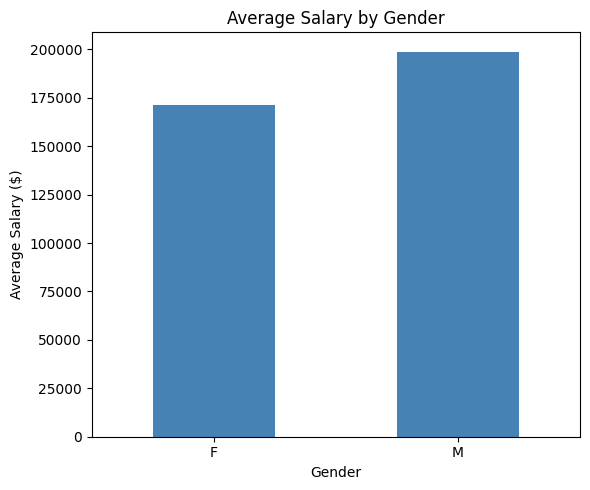

In [102]:
plt.figure(figsize=(6,5))
df_model.groupby('sex')['salary'].mean().plot(kind='bar', color='steelblue')
plt.title('Average Salary by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Salary ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Plot 2: Average Salary by Department

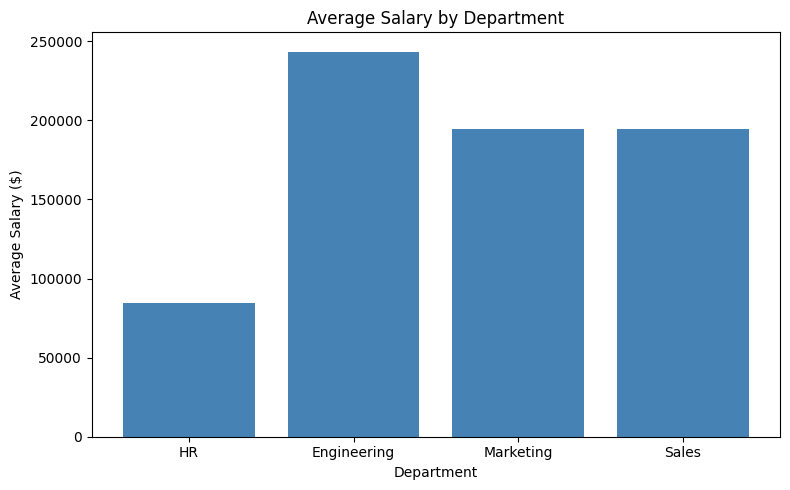

In [103]:
dept_salary = {
    'HR': df_model[df_model['dept_HR'] == 1]['salary'].mean(),
    'Engineering': df_model[df_model['dept_engineering'] == 1]['salary'].mean(),
    'Marketing': df_model[df_model['dept_marketing'] == 1]['salary'].mean(),
    'Sales': df_model[df_model['dept_sales'] == 1]['salary'].mean()
}

plt.figure(figsize=(8,5))
plt.bar(dept_salary.keys(), dept_salary.values(), color='steelblue')
plt.title('Average Salary by Department')
plt.xlabel('Department')
plt.ylabel('Average Salary ($)')
plt.tight_layout()
plt.show()

Plot 3: Average Salary by Level

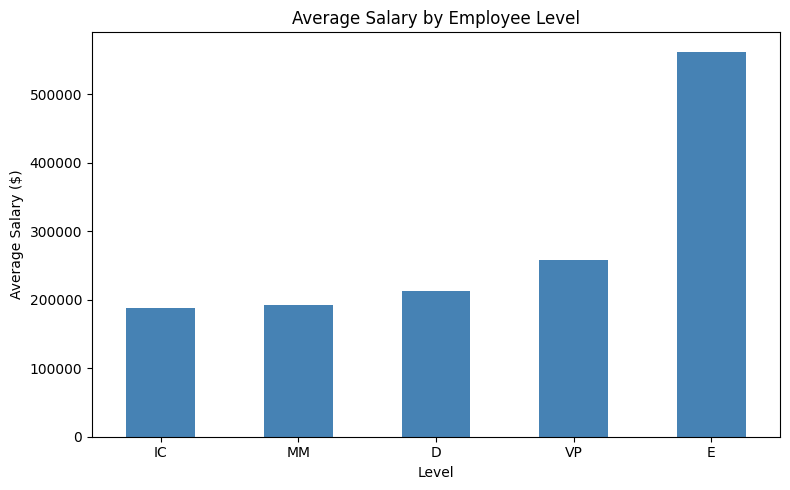

In [104]:
level_map_reverse = {0:'IC', 1:'MM', 2:'D', 3:'VP', 4:'E', 5:'CEO'}
df_model['level_label'] = df_model['level_encoded'].map(level_map_reverse)

plt.figure(figsize=(8,5))
df_model.groupby('level_label')['salary'].mean().reindex(
    ['IC','MM','D','VP','E']
).plot(kind='bar', color='steelblue')
plt.title('Average Salary by Employee Level')
plt.xlabel('Level')
plt.ylabel('Average Salary ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Plot 4: Average Salary by Degree

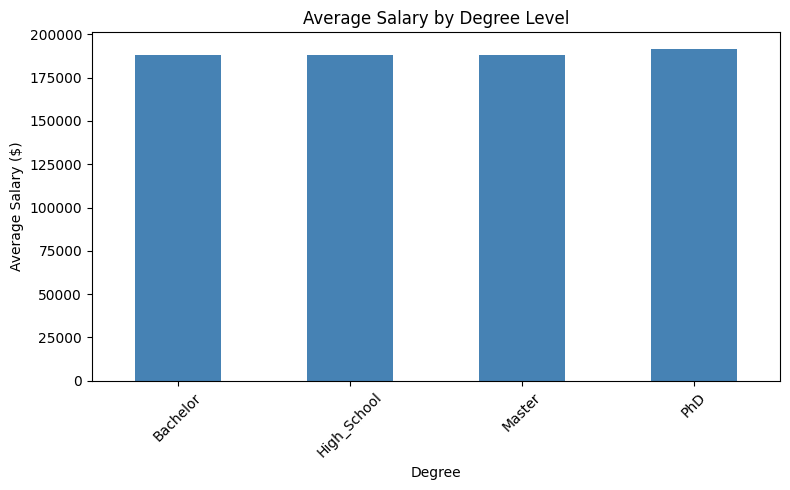

In [105]:
plt.figure(figsize=(8,5))
df_model.groupby('degree_level')['salary'].mean().plot(
    kind='bar', color='steelblue'
)
plt.title('Average Salary by Degree Level')
plt.xlabel('Degree')
plt.ylabel('Average Salary ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Task 4: Fairness Analysis and HR Recommendations

### Key Salary Drivers
1. **Department** -- strongest driver by far
2. **Years of Experience** -- moderate impact
3. **Total People Managed** -- moderate impact
4. **Degree Level** -- minimal impact
5. **Gender** -- near zero impact across all models

---

### Fairness Findings

**Finding 1: No Direct Gender Discrimination Detected**
Males average ~$200K vs females ~$172K, a $28K surface gap. However 
all three models assigned near zero importance to gender after 
controlling for other factors. Gap is likely explained by female 
employees being concentrated in HR, the lowest paid department.

**Finding 2: Severe Department Pay Gap (Critical)**
HR averages $84,560 vs Engineering at $243,525, a $160K gap. HR was 
the dominant salary predictor across all models at 58% to 80% feature 
importance. Most urgent fairness concern in this dataset.

**Finding 3: Level Progression is Fair**
Salary increases consistently from IC through Executive. Seniority 
is being rewarded appropriately.

**Finding 4: Degree is Not Being Rewarded**
PhD and High School employees earn essentially the same salary. 
Inconsistent with standard compensation practices.

---

### Recommendations to Head of HR

**1. Investigate HR Compensation Urgently**
Benchmark HR salaries against market rates and adjust if below 
industry standard.

**2. Audit Gender Distribution by Department**
Investigate whether female employees are disproportionately placed 
in lower paying departments and whether promotion practices are fair.

**3. Revisit Degree Based Pay Policy**
If advanced degrees are required in hiring, compensation should 
reflect that.

**4. Collect Better Data**
65% of salary variance is unexplained. Add performance ratings, 
tenure, and location data to enable stronger future analysis.